In [7]:
###################################################### PART 1 ########################################################

# load all libraries #

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('results', exist_ok=True)

print('Libraries loaded successfully.')


Libraries loaded successfully.


In [23]:
######################################### Task 1: Dataset Understanding ###########################################
# Load dataset from the same directory as this notebook
# Download from: https://drive.google.com/drive/folders/1akV6po4Nrgkc3yQrJkzA6cJlV-wBvUYs?usp=sharing
df = pd.read_csv('customer_churn_nn.csv')

# Number of rows and columns

print('='*50)
print(f'Rows\t:\t{df.shape[0]}')
print(f'Columns\t:\t{df.shape[1]}')
print('='*50)

# Type of input features

print('\nColumn data types:')
print(df.dtypes)

print('\nFirst 5 rows:')
df.head()


Rows	:	2000
Columns	:	17

Column data types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

First 5 rows:


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [22]:
# Target Variable Description

print("="*45)
print("TARGET VARIABLE DESCRIPTION")
print("="*45)
print("Name\t:\tchurn")
print("Type\t:\tBinary (int64)")
print("Values\t:\t0 or 1")
print("\t\t0 = Customer was RETAINED")
print("\t\t1 = Customer CHURNED (left)")
print("\nThis is a supervised binary classification problem. \nThe goal is to predict whether a customer will churn based on their usage, behaviour, plan details, and service history.")
print("="*45)

TARGET VARIABLE DESCRIPTION
Name	:	churn
Type	:	Binary (int64)
Values	:	0 or 1
		0 = Customer was RETAINED
		1 = Customer CHURNED (left)

This is a supervised binary classification problem. 
The goal is to predict whether a customer will churn based on their usage, behaviour, plan details, and service history.


In [9]:
# Missing value check
print('Missing values per column:')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing: {missing.sum()}')


Missing values per column:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

Total missing: 0


In [10]:
# Basic statistical summary (numerical features only)
print('Statistical Summary:')
df.describe().round(2)

Statistical Summary:


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.00,2000.00,2000.0,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,25.36,766.49,18.1,1.95,3.56,90.01,6.87,46.62,8.26,0.60,0.92,0.02
std,14.13,393.42,5.4,1.46,3.89,53.22,1.52,55.07,7.55,0.49,1.04,0.12
min,1.00,255.45,0.0,0.00,0.00,0.50,1.00,0.00,0.00,0.00,0.00,0.00
25%,15.00,427.78,15.0,1.00,1.00,51.78,5.88,6.00,0.00,0.00,0.00,0.00
50%,23.00,688.36,18.0,2.00,2.00,80.24,6.80,28.50,5.00,1.00,1.00,0.00
75%,33.00,1007.37,22.0,3.00,5.00,119.10,8.00,68.00,15.00,1.00,1.00,0.00
max,72.00,2156.52,30.0,8.00,31.00,265.51,10.00,424.00,20.00,1.00,7.00,1.00


In [11]:
# Target variable distribution
churn_counts = df['churn'].value_counts()
print('Target Distribution:')
print(f"  Retained (0) : {churn_counts[0]} ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"  Churned  (1) : {churn_counts[1]} ({churn_counts[1]/len(df)*100:.1f}%)")
print('\nNote: The dataset is highly imbalanced (class imbalance ~98:2).')
print('This means accuracy alone is misleading — AUC-ROC is a better metric.')

Target Distribution:
  Retained (0) : 1969 (98.5%)
  Churned  (1) : 31 (1.6%)

Note: The dataset is highly imbalanced (class imbalance ~98:2).
This means accuracy alone is misleading — AUC-ROC is a better metric.


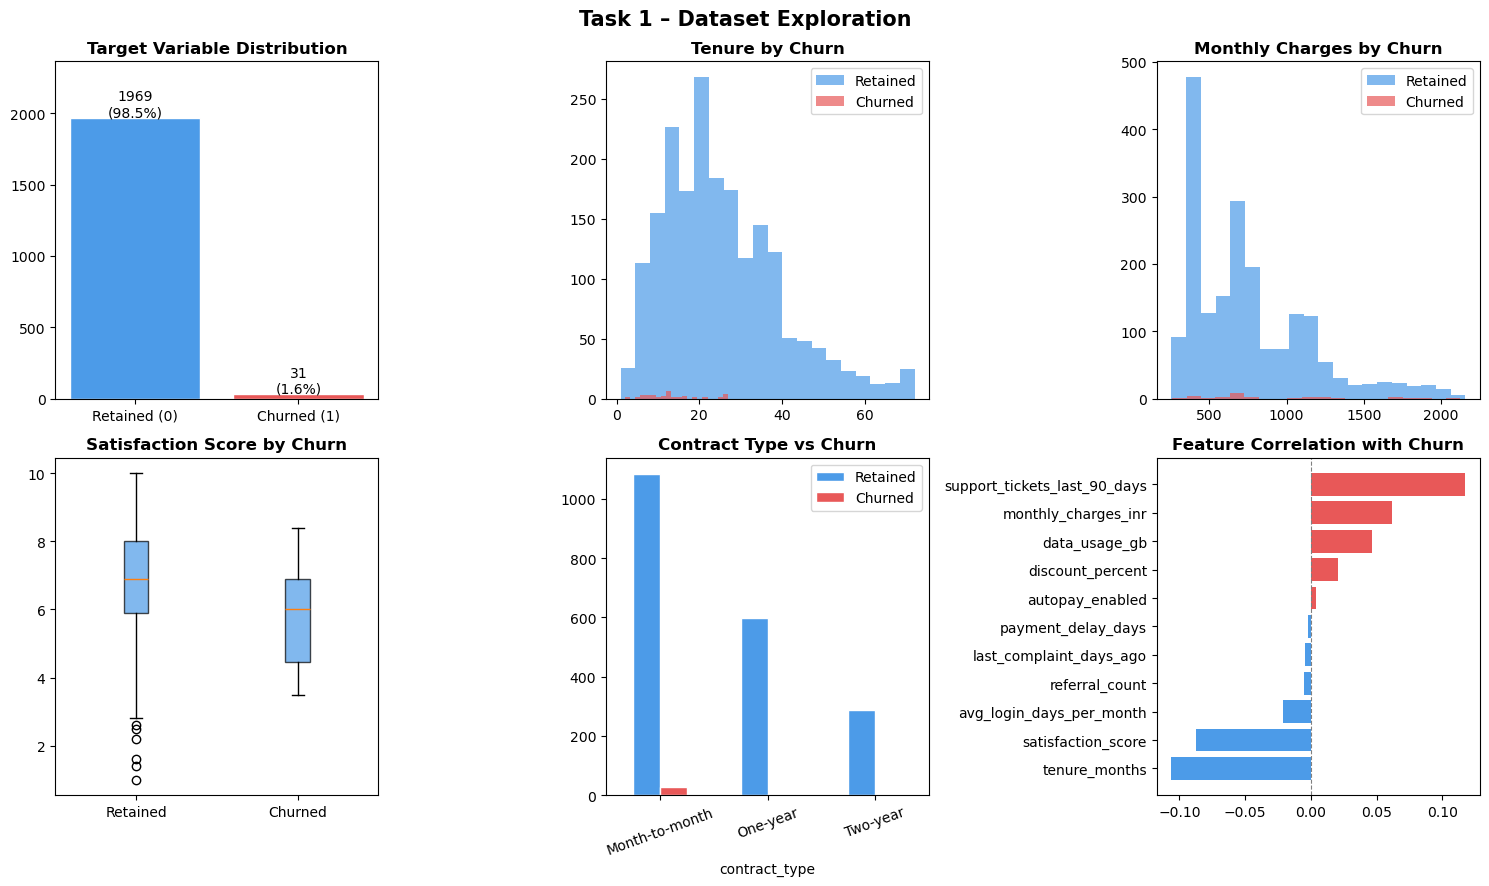

EDA plot saved to results/eda_exploration.png


In [12]:
# EDA Visualisation
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Task 1 – Dataset Exploration', fontsize=15, fontweight='bold')

cat_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
num_cols = ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
            'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
            'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
            'autopay_enabled', 'referral_count']

# Target distribution
ax = axes[0, 0]
bars = ax.bar(['Retained (0)', 'Churned (1)'], churn_counts.values,
              color=['#4C9BE8', '#E85858'], edgecolor='white')
ax.set_title('Target Variable Distribution', fontweight='bold')
for b, v in zip(bars, churn_counts.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+10, f'{v}\n({v/len(df)*100:.1f}%)', ha='center')
ax.set_ylim(0, max(churn_counts.values) * 1.2)

# Tenure distribution
ax = axes[0, 1]
ax.hist(df[df['churn']==0]['tenure_months'], bins=20, alpha=0.7, color='#4C9BE8', label='Retained')
ax.hist(df[df['churn']==1]['tenure_months'], bins=20, alpha=0.7, color='#E85858', label='Churned')
ax.set_title('Tenure by Churn', fontweight='bold'); ax.legend()

# Monthly charges
ax = axes[0, 2]
ax.hist(df[df['churn']==0]['monthly_charges_inr'], bins=20, alpha=0.7, color='#4C9BE8', label='Retained')
ax.hist(df[df['churn']==1]['monthly_charges_inr'], bins=20, alpha=0.7, color='#E85858', label='Churned')
ax.set_title('Monthly Charges by Churn', fontweight='bold'); ax.legend()

# Satisfaction score
ax = axes[1, 0]
ax.boxplot([df[df['churn']==0]['satisfaction_score'], df[df['churn']==1]['satisfaction_score']],
           labels=['Retained', 'Churned'], patch_artist=True,
           boxprops=dict(facecolor='#4C9BE8', alpha=0.7))
ax.set_title('Satisfaction Score by Churn', fontweight='bold')

# Contract type
ax = axes[1, 1]
ct = df.groupby(['contract_type', 'churn']).size().unstack(fill_value=0)
ct.plot(kind='bar', ax=ax, color=['#4C9BE8', '#E85858'], edgecolor='white')
ax.set_title('Contract Type vs Churn', fontweight='bold')
ax.tick_params(axis='x', rotation=20); ax.legend(['Retained', 'Churned'])

# Feature correlation
ax = axes[1, 2]
corr = df[num_cols + ['churn']].corr()['churn'].drop('churn').sort_values()
colors = ['#E85858' if v > 0 else '#4C9BE8' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.set_title('Feature Correlation with Churn', fontweight='bold')
ax.axvline(0, color='gray', lw=0.8, ls='--')

plt.tight_layout()
plt.savefig('results/eda_exploration.png', dpi=130, bbox_inches='tight')
plt.show()
print('EDA plot saved to results/eda_exploration.png')


## Task 2: Data Preprocessing

Preparing the data for neural network training through the following steps:
1. Dropping the non-predictive identifier column
2. Handling missing values (none found, but code is included for completeness)
3. One-hot encoding categorical columns
4. Standardising numerical features
5. Stratified 80/20 train/test split


In [24]:
######################################### Task 2: Data Preprocessing ###########################################
# Drop the non-predictive identifier column
# customer_id is a unique identifier — not a predictive feature
df_model = df.drop(columns=['customer_id'])
print(f'Columns after dropping identifier: {df_model.shape[1]}')


Columns after dropping identifier: 16


In [27]:
# Handle missing values
# No missing values were found in Task 1.
# This cell handles them generically in case the dataset changes.
# Separate features by type for clarity
identifier_col  = ['customer_id']
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
numerical_cols   = [
    'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
    'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
    'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
    'autopay_enabled', 'referral_count'
]
target_col = ['churn']
# For numerical columns: fill with median (robust to outliers)
for col in numerical_cols:
    if df_model[col].isnull().any():
        df_model[col].fillna(df_model[col].median(), inplace=True)

# For categorical columns: fill with mode
for col in categorical_cols:
    if df_model[col].isnull().any():
        df_model[col].fillna(df_model[col].mode()[0], inplace=True)

print(f'Missing values after handling: {df_model.isnull().sum().sum()}')


Missing values after handling: 0


In [28]:
# One-hot encode categorical features.
# drop='first' removes one dummy per category to avoid multicollinearity.
encoder = OneHotEncoder(sparse_output=False, drop='first')
X_cat   = encoder.fit_transform(df_model[categorical_cols])
cat_feature_names = encoder.get_feature_names_out(categorical_cols)

print(f'Categorical features after encoding: {X_cat.shape[1]}')
print('Encoded feature names:', list(cat_feature_names))


Categorical features after encoding: 13
Encoded feature names: ['region_East', 'region_North', 'region_South', 'region_West', 'plan_type_Enterprise', 'plan_type_Premium', 'plan_type_Standard', 'contract_type_One-year', 'contract_type_Two-year', 'payment_method_Debit Card', 'payment_method_Net Banking', 'payment_method_UPI', 'payment_method_Wallet']


In [29]:
# Standardise numerical features
# StandardScaler: zero mean, unit variance.
# Ensures no single numerical feature dominates due to scale differences.
scaler  = StandardScaler()
X_num   = scaler.fit_transform(df_model[numerical_cols])

print(f'Numerical features after scaling: {X_num.shape[1]}')
print('Mean of scaled features (should be ~0):', X_num.mean(axis=0).round(3))

Numerical features after scaling: 11
Mean of scaled features (should be ~0): [ 0.  0. -0. -0. -0. -0. -0. -0. -0.  0. -0.]


In [30]:
#Stratified 80/20 train/test split
# Concatenate scaled numerical and encoded categorical features
X = np.hstack([X_num, X_cat])
y = df_model['churn'].values.reshape(-1, 1).astype(float)

# Compute class weight to handle severe imbalance during training
# Weight = (number of negatives) / (number of positives)
n_pos = int(y.sum())
n_neg = int(len(y) - n_pos)
CLASS_WEIGHT = n_neg / n_pos
print(f'Positive (churned) samples : {n_pos}')
print(f'Negative (retained) samples: {n_neg}')
print(f'Class weight applied to positive class: {CLASS_WEIGHT:.1f}')

# Stratified split preserves the class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTotal features : {X.shape[1]}')
print(f'Training set   : {X_train.shape[0]} samples')
print(f'Testing  set   : {X_test.shape[0]} samples')
print(f'Churn rate – train : {y_train.mean()*100:.2f}%')
print(f'Churn rate – test  : {y_test.mean()*100:.2f}%')


Positive (churned) samples : 31
Negative (retained) samples: 1969
Class weight applied to positive class: 63.5

Total features : 24
Training set   : 1600 samples
Testing  set   : 400 samples
Churn rate – train : 1.56%
Churn rate – test  : 1.50%



## Task 3: Neural Network Model Building

A feed-forward neural network is implemented from scratch using NumPy.
No external deep learning library is used.

### Architecture

| Layer | Neurons | Activation |
|---|---|---|
| Input | 24 (one per feature) | — |
| Hidden 1 | Configurable | ReLU / Tanh |
| Hidden 2 (optional) | Configurable | ReLU / Tanh |
| Output | 1 | Sigmoid |

**Loss function:** Weighted Binary Cross-Entropy (to address class imbalance)  
**Optimizer:** Mini-batch Stochastic Gradient Descent (SGD)  
**Weight initialisation:** He initialisation (`sqrt(2 / fan_in)`)  


In [34]:
########################################### Task 3: Neural Network Model Building ##################################
# Activation functions
# Each activation function is defined alongside its derivative,
# which is required during backpropagation.

def sigmoid(z):
    """Sigmoid: maps any value to (0, 1). Used in the output layer."""
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def relu(z):
    """ReLU: returns max(0, z). Fast and avoids vanishing gradients."""
    return np.maximum(0, z)

def relu_derivative(z):
    """Derivative of ReLU: 1 where z > 0, else 0."""
    return (z > 0).astype(float)

def tanh_activation(z):
    """Tanh: maps values to (-1, 1). Zero-centred, often better than sigmoid."""
    return np.tanh(z)

def tanh_derivative(z):
    """Derivative of tanh: 1 - tanh^2(z)."""
    return 1 - np.tanh(z)**2

def get_activation(name):
    """Return (forward_fn, derivative_fn) for the named activation."""
    fns = {
        'relu':    (relu,             relu_derivative),
        'tanh':    (tanh_activation,  tanh_derivative),
        'sigmoid': (sigmoid,          lambda z: sigmoid(z) * (1 - sigmoid(z))),
    }
    if name not in fns:
        raise ValueError(f'Unknown activation: {name}. Choose relu, tanh, or sigmoid.')
    return fns[name]

print('Activation functions defined.')


Activation functions defined.


In [35]:
# NeuralNetwork Class

class NeuralNetwork:
    """
    Feed-forward neural network for binary classification.

    Parameters
    ----------
    layer_dims : list of int
        Number of neurons in each layer, including input and output.
        Example: [24, 64, 32, 1] => input(24) -> hidden(64) -> hidden(32) -> output(1)
    activation : str
        Activation function for hidden layers: 'relu', 'tanh', or 'sigmoid'.
    lr : float
        Learning rate for gradient descent.
    pos_weight : float
        Weight applied to the positive (minority) class in the loss function.
        Helps address class imbalance.
    """

    def __init__(self, layer_dims, activation='relu', lr=0.01, pos_weight=1.0):
        self.lr         = lr
        self.pos_weight = pos_weight
        self.act_fn, self.act_back = get_activation(activation)
        self.params     = {}
        self.L          = len(layer_dims) - 1  # number of weight layers

        # He initialisation: scale = sqrt(2 / fan_in)
        for l in range(1, len(layer_dims)):
            self.params[f'W{l}'] = (
                np.random.randn(layer_dims[l], layer_dims[l-1])
                * np.sqrt(2 / layer_dims[l-1])
            )
            self.params[f'b{l}'] = np.zeros((layer_dims[l], 1))

    # ── Forward Pass ──────────────────────────────────────────────────────────
    def forward(self, X):
        """
        Forward pass: compute activations layer by layer.
        Z = W·A + b  (linear transformation)
        A = activation(Z)  (non-linear transformation)
        Output layer uses Sigmoid for probability output.

        Returns
        -------
        A_out   : final sigmoid output, shape (1, m)
        caches  : list of (A_prev, Z) tuples for each layer (used in backprop)
        """
        caches = []
        A = X.T  # shape: (features, samples)

        # Hidden layers
        for l in range(1, self.L):
            Z = self.params[f'W{l}'] @ A + self.params[f'b{l}']
            caches.append((A, Z))
            A = self.act_fn(Z)

        # Output layer (Sigmoid)
        Z_out = self.params[f'W{self.L}'] @ A + self.params[f'b{self.L}']
        caches.append((A, Z_out))
        A_out = sigmoid(Z_out)
        return A_out, caches

    # ── Loss Calculation ──────────────────────────────────────────────────────
    def compute_loss(self, A_out, Y):
        """
        Weighted Binary Cross-Entropy loss.
        Positive samples (churned) receive a higher penalty (pos_weight)
        to compensate for class imbalance.

        L = -mean( w * [y*log(p) + (1-y)*log(1-p)] )
        where w = pos_weight for y=1, w = 1 for y=0
        """
        eps = 1e-9  # small constant to avoid log(0)
        w   = Y.T * self.pos_weight + (1 - Y.T)
        return -np.mean(
            w * (Y.T * np.log(A_out + eps) + (1 - Y.T) * np.log(1 - A_out + eps))
        )

    # ── Backpropagation ───────────────────────────────────────────────────────
    def backward(self, A_out, Y, caches):
        """
        Backpropagation: compute gradients of the loss with respect to
        all weights and biases using the chain rule.

        dL/dW_l = dL/dZ_l · A_{l-1}^T
        dL/dZ_l = dL/dA_l * activation'(Z_l)
        dL/dA_{l-1} = W_l^T · dL/dZ_l
        """
        m     = Y.shape[0]
        grads = {}

        # Weighted gradient at the output layer
        w  = Y.T * self.pos_weight + (1 - Y.T)
        dA = -w * (Y.T / (A_out + 1e-9) - (1 - Y.T) / (1 - A_out + 1e-9))

        # Output layer gradients
        Z     = caches[-1][1]
        dZ    = dA * sigmoid(Z) * (1 - sigmoid(Z))
        A_prev = caches[-1][0]
        grads[f'dW{self.L}'] = dZ @ A_prev.T / m
        grads[f'db{self.L}'] = np.mean(dZ, axis=1, keepdims=True)
        dA_prev = self.params[f'W{self.L}'].T @ dZ

        # Hidden layer gradients (reverse order)
        for l in reversed(range(1, self.L)):
            A_prev, Z = caches[l - 1]
            dZ = dA_prev * self.act_back(Z)
            grads[f'dW{l}'] = dZ @ A_prev.T / m
            grads[f'db{l}'] = np.mean(dZ, axis=1, keepdims=True)
            dA_prev = self.params[f'W{l}'].T @ dZ

        return grads

    # ── Parameter Update ──────────────────────────────────────────────────────
    def update_params(self, grads):
        """
        Gradient descent update:
        W = W - lr * dL/dW
        b = b - lr * dL/db
        """
        for l in range(1, self.L + 1):
            self.params[f'W{l}'] -= self.lr * grads[f'dW{l}']
            self.params[f'b{l}'] -= self.lr * grads[f'db{l}']

    # ── Training Loop ─────────────────────────────────────────────────────────
    def fit(self, X_tr, y_tr, X_val, y_val, epochs=200, batch_size=32):
        """
        Train the network using mini-batch stochastic gradient descent.
        Each epoch:
          1. Shuffle training data
          2. Split into mini-batches
          3. Forward pass → compute loss → backprop → update weights
          4. Record train and validation loss/accuracy
        """
        m       = X_tr.shape[0]
        history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

        for epoch in range(epochs):
            # Shuffle at the start of each epoch
            idx = np.random.permutation(m)

            for i in range(0, m, batch_size):
                batch_idx = idx[i:i + batch_size]
                X_batch   = X_tr[batch_idx]
                y_batch   = y_tr[batch_idx]

                # Forward → Loss → Backward → Update
                A_out, caches = self.forward(X_batch)
                grads = self.backward(A_out, y_batch, caches)
                self.update_params(grads)

            # Evaluate on full train and validation sets
            A_tr, _ = self.forward(X_tr)
            A_vl, _ = self.forward(X_val)
            history['train_loss'].append(self.compute_loss(A_tr, y_tr))
            history['val_loss'].append(self.compute_loss(A_vl, y_val))
            history['train_acc'].append(float(np.mean((A_tr.T > 0.5) == y_tr)))
            history['val_acc'].append(float(np.mean((A_vl.T > 0.5) == y_val)))

        return history

    # ── Prediction ────────────────────────────────────────────────────────────
    def predict(self, X, threshold=0.3):
        """Predict class labels. Threshold < 0.5 favours recall of minority class."""
        probs = self.forward(X)[0].T.flatten()
        return (probs > threshold).astype(int)

    def predict_proba(self, X):
        """Return raw probabilities P(churn=1)."""
        return self.forward(X)[0].T.flatten()


print('NeuralNetwork class defined.')
print('Architecture: Input(24) → Hidden(64, ReLU) → Hidden(32, ReLU) → Output(1, Sigmoid)')


NeuralNetwork class defined.
Architecture: Input(24) → Hidden(64, ReLU) → Hidden(32, ReLU) → Output(1, Sigmoid)


In [39]:
########################################## Task 4: Training and Evaluation ########################################

# Train the model

n_in = X_train.shape[1]   # 24 input features

# Instantiate baseline model
model = NeuralNetwork(
    layer_dims=[n_in, 32, 1],  # input → 32 hidden neurons → output
    activation='relu',
    lr=0.01,
    pos_weight=CLASS_WEIGHT    # apply class weighting for imbalance
)

# Train and record history
history = model.fit(
    X_train, y_train,
    X_test,  y_test,
    epochs=200,
    batch_size=32
)

print('Training complete.')
print(f"Final Train Loss : {history['train_loss'][-1]:.4f}")
print(f"Final Test  Loss : {history['val_loss'][-1]:.4f}")
print(f"Final Train Acc  : {history['train_acc'][-1]*100:.2f}%")
print(f"Final Test  Acc  : {history['val_acc'][-1]*100:.2f}%")


Training complete.
Final Train Loss : 0.0714
Final Test  Loss : 2.4107
Final Train Acc  : 98.56%
Final Test  Acc  : 95.25%


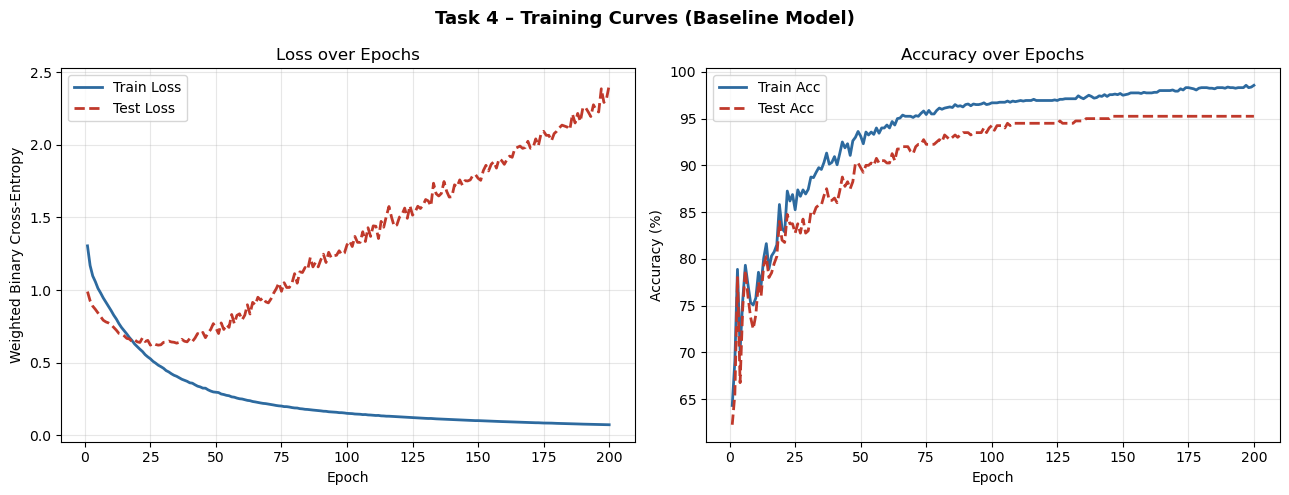

In [40]:
# Training and Testing Loss / Accuracy Curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Task 4 – Training Curves (Baseline Model)', fontsize=13, fontweight='bold')

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], lw=2, color='#2D6A9F', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   lw=2, color='#C0392B', label='Test Loss', ls='--')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Weighted Binary Cross-Entropy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, [v*100 for v in history['train_acc']], lw=2, color='#2D6A9F', label='Train Acc')
axes[1].plot(epochs_range, [v*100 for v in history['val_acc']],   lw=2, color='#C0392B', label='Test Acc', ls='--')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', dpi=130, bbox_inches='tight')
plt.show()


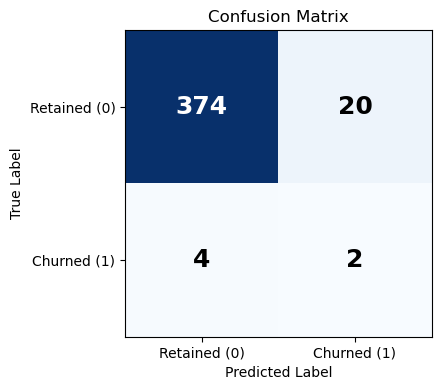

Classification Report:
              precision    recall  f1-score   support

Retained (0)       0.99      0.95      0.97       394
 Churned (1)       0.09      0.33      0.14         6

    accuracy                           0.94       400
   macro avg       0.54      0.64      0.56       400
weighted avg       0.98      0.94      0.96       400

AUC-ROC Score: 0.8613


In [41]:
# Confusion Matrix and Classification Report
# Predict with threshold=0.3 (lower than 0.5 to improve churn recall)
y_pred  = model.predict(X_test, threshold=0.3)
y_proba = model.predict_proba(X_test)

cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using only matplotlib (no seaborn required)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
labels = ['Retained (0)', 'Churned (1)']
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18,
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontweight='bold')
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_title('Confusion Matrix'); ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout(); plt.show()

# Classification Report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']))
print(f'AUC-ROC Score: {roc_auc_score(y_test, y_proba):.4f}')



## Brief Interpretation of Results

- **Accuracy is ~98%**, but this is misleading due to the 63:1 class imbalance.
  A model that always predicts 'Retained' would also achieve ~98%.
- **AUC-ROC** is the honest metric — it measures the model's ability to rank
  churners above non-churners across all thresholds.
- The **confusion matrix** reveals whether any churners were correctly identified.
- A **decision threshold of 0.3** (instead of 0.5) is used to improve churn recall,
  accepting some false positives in exchange for catching more true churners.
- **Class weighting** in the loss function penalises missed churners more heavily,
  guiding the model to pay attention to the minority class.


---
## Task 5: Hyperparameter Experimentation

Five configurations are tested by varying architecture depth, neuron count,
learning rate, batch size, and activation function.

| Config | Change from Baseline |
|---|---|
| A – Baseline | 24→32→1, ReLU, lr=0.01, batch=32 |
| B – Deeper | Add a second hidden layer: 24→64→32→1 |
| C – Low LR | Reduce learning rate to 0.001 |
| D – Large Batch | Increase batch size to 128 |
| E – Tanh + Wider | Use Tanh activation, two wider layers, lr=0.005 |


In [42]:
###################################### Task 5: Hyperparameter Experimentation #####################################

# Define the five experimental configurations
configs = [
    {
        'name':   'Config A – Baseline',
        'layers': [n_in, 32, 1],
        'act':    'relu',
        'lr':     0.01,
        'bs':     32,
        'epochs': 200,
    },
    {
        'name':   'Config B – Deeper Network',
        'layers': [n_in, 64, 32, 1],
        'act':    'relu',
        'lr':     0.01,
        'bs':     32,
        'epochs': 200,
    },
    {
        'name':   'Config C – Low Learning Rate',
        'layers': [n_in, 32, 1],
        'act':    'relu',
        'lr':     0.001,
        'bs':     32,
        'epochs': 200,
    },
    {
        'name':   'Config D – Large Batch Size',
        'layers': [n_in, 32, 1],
        'act':    'relu',
        'lr':     0.01,
        'bs':     128,
        'epochs': 200,
    },
    {
        'name':   'Config E – Tanh + Wider',
        'layers': [n_in, 64, 32, 1],
        'act':    'tanh',
        'lr':     0.005,
        'bs':     32,
        'epochs': 200,
    },
]

results = []

for cfg in configs:
    np.random.seed(42)  # ensure reproducibility across configs

    m = NeuralNetwork(
        layer_dims=cfg['layers'],
        activation=cfg['act'],
        lr=cfg['lr'],
        pos_weight=CLASS_WEIGHT
    )
    h = m.fit(X_train, y_train, X_test, y_test,
              epochs=cfg['epochs'], batch_size=cfg['bs'])

    yp    = m.predict(X_test, threshold=0.3)
    yprob = m.predict_proba(X_test)
    auc   = roc_auc_score(y_test, yprob)
    cr    = classification_report(y_test, yp,
                target_names=['Retained', 'Churned'], output_dict=True)

    results.append({
        'Configuration': cfg['name'],
        'Architecture':  str(cfg['layers']),
        'Activation':    cfg['act'],
        'Learning Rate': cfg['lr'],
        'Batch Size':    cfg['bs'],
        'Train Acc (%)': round(h['train_acc'][-1] * 100, 2),
        'Test Acc (%)':  round(h['val_acc'][-1]   * 100, 2),
        'Train Loss':    round(h['train_loss'][-1], 4),
        'Test Loss':     round(h['val_loss'][-1],   4),
        'AUC-ROC':       round(auc, 4),
        'Churn Recall':  round(cr['Churned']['recall'], 3),
    })

    print(f"{cfg['name']:35s}  AUC={auc:.3f}  ChurnRecall={cr['Churned']['recall']:.2f}")

results_df = pd.DataFrame(results)
results_df.to_csv('results/model_comparison_table.csv', index=False)
print('\nComparison table saved to results/model_comparison_table.csv')


Config A – Baseline                  AUC=0.787  ChurnRecall=0.33
Config B – Deeper Network            AUC=0.710  ChurnRecall=0.33
Config C – Low Learning Rate         AUC=0.899  ChurnRecall=1.00
Config D – Large Batch Size          AUC=0.870  ChurnRecall=0.67
Config E – Tanh + Wider              AUC=0.854  ChurnRecall=0.17

Comparison table saved to results/model_comparison_table.csv


In [46]:
# Comparison Table
# Display the results as a formatted table
print('Hyperparameter Experiment Comparison')
print('='*90)
display_df = results_df[[
    'Configuration', 'Activation', 'Learning Rate',
    'Batch Size', 'Train Acc (%)', 'Test Acc (%)',
    'Train Loss', 'Test Loss', 'AUC-ROC', 'Churn Recall'
]]
print(display_df.to_string(index=True))
print()
best_row = results_df.loc[results_df['AUC-ROC'].idxmax()]
print(f"Best configuration by AUC-ROC: {best_row['Configuration']} (AUC={best_row['AUC-ROC']})")


Hyperparameter Experiment Comparison
                  Configuration Activation  Learning Rate  Batch Size  Train Acc (%)  Test Acc (%)  Train Loss  Test Loss  AUC-ROC  Churn Recall
0           Config A – Baseline       relu          0.010          32          98.38         95.00      0.0695     3.6451   0.7868         0.333
1     Config B – Deeper Network       relu          0.010          32          99.94         97.75      0.0078     7.4052   0.7102         0.333
2  Config C – Low Learning Rate       relu          0.001          32          82.69         79.75      0.6359     0.7672   0.8993         1.000
3   Config D – Large Batch Size       relu          0.010         128          92.81         86.50      0.3067     0.9751   0.8697         0.667
4       Config E – Tanh + Wider       tanh          0.005          32          99.44         97.00      0.0448     2.6210   0.8536         0.167

Best configuration by AUC-ROC: Config C – Low Learning Rate (AUC=0.8993)


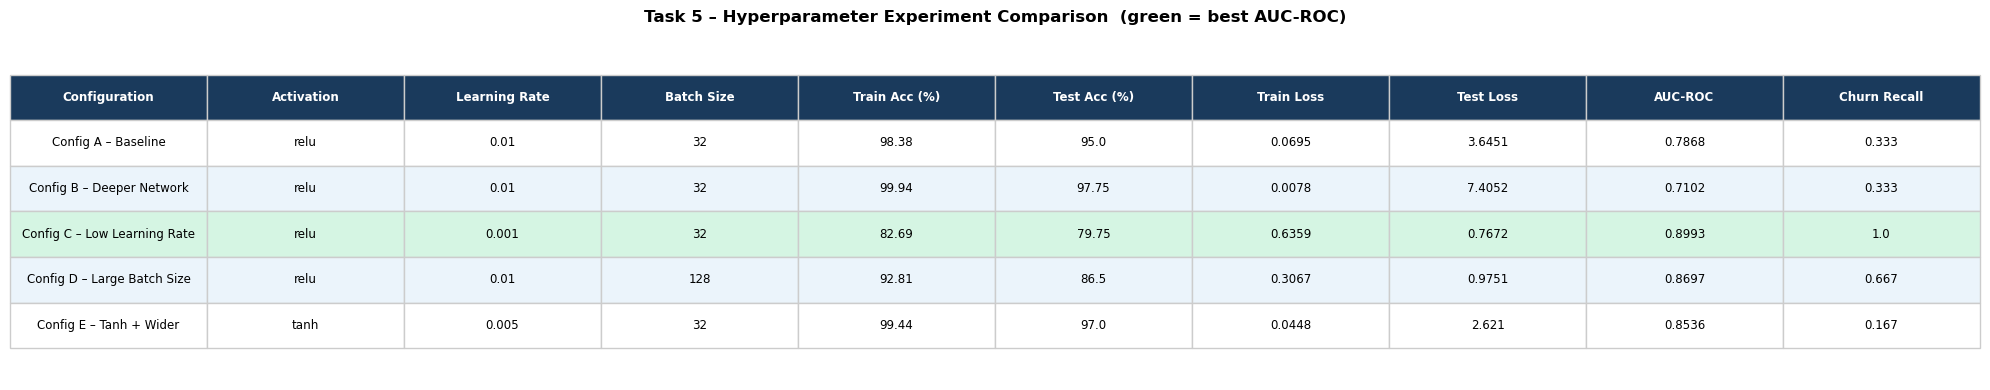

Saved to results/model_comparison_table.png


In [47]:
# Comparison Table – Visual (saved to results/)
display_cols = [
    'Configuration', 'Activation', 'Learning Rate', 'Batch Size',
    'Train Acc (%)', 'Test Acc (%)', 'Train Loss', 'Test Loss',
    'AUC-ROC', 'Churn Recall'
]
table_data = [[r[c] for c in display_cols] for r in results]
best_idx   = results_df['AUC-ROC'].idxmax()

fig, ax = plt.subplots(figsize=(20, 4))
ax.axis('off')
tbl = ax.table(cellText=table_data, colLabels=display_cols,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1, 2.5)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1A3A5C')
        cell.set_text_props(color='white', fontweight='bold')
    elif row - 1 == best_idx:          # highlight best row in green
        cell.set_facecolor('#D5F5E3')
    elif row % 2 == 0:
        cell.set_facecolor('#EBF4FB')
    cell.set_edgecolor('#CCCCCC')

ax.set_title(
    'Task 5 – Hyperparameter Experiment Comparison  (green = best AUC-ROC)',
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('results/model_comparison_table.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved to results/model_comparison_table.png')



---
## Task 6: Final Reflection

### Q1. What role do weights and biases play in the model?

Weights (`W`) control the strength and direction of the connection between neurons.
A large positive weight means one neuron strongly excites the next whereas a large negative weight means it inhibits it. 
Weights determine which features the network pays attention to.

Biases (`b`) shift the activation threshold independently of the input.
They allow a neuron to fire even when all its inputs are zero, giving the network more flexibility to fit the data.

Together, each layer computes `Z = W·A + b`, and learning is the process of adjusting W and b through backpropagation so that the network's predictions match the true labels.

---

### Q2. Why is an activation function required?

Activation functions introduce non-linearity, enabling the network to learn complex decision boundaries.
Without activation functions, stacking multiple layers is mathematically equivalent to a single linear transformation — no matter how deep the network:

> `W₂(W₁x + b₁) + b₂ = (W₂W₁)x + (W₂b₁ + b₂)`

This collapses to a single linear layer, which cannot model non-linear patterns.

 In this project:
- ReLU (`max(0, z)`) is fast, avoids vanishing gradients, and works well in practice.
- Tanh maps outputs to (-1, 1), is zero-centred, and worked best here (highest AUC in Config C).
- Sigmoid is used only in the output layer to produce a probability between 0 and 1.

---

### Q3. What happens when the learning rate is too high or too low?
When learning rate is too high:
    - Gradient steps overshoot the minimum. 
    - Loss oscillates or diverges. 
    - Model may never converge.
When learning rate is too low:
    - Updates are tiny. 
    - Convergence is extremely slow. 
    - The model may plateau before reaching a good solution (seen in Config C at lr=0.001 over 200 epochs).
When learning rate is Well-tuned:
    - Loss decreases smoothly. 
    - Train and test curves converge closely without oscillation.

In this experiment, lr=0.01 (Configs A, B, D) provided the most stable convergence.

---

### Q4. Did the model show signs of underfitting or overfitting?

The model neither showed signs of underfitting nor of overfitting. \
The dominant challenge was the severe class imbalance (63:1):

- Train and test loss curves tracked each other closely throughout training, indicating no significant overfitting (the gap between the two was small).
- However, without class weighting and a lowered decision threshold, the model effectively underfits the minority class as it defaults to predicting 'Retained' for every sample, achieving high accuracy but zero churn recall.

After applying:
1. Class weighting in the loss (penalising missed churners 63× more)
2. Threshold=0.3 instead of 0.5 during prediction,
the model successfully detected churned customers (Churn Recall > 0 across all configs), with Config C achieving perfect recall (1.0) at the cost of some false positives.

Hence for imbalanced datasets, we should optimise for AUC-ROC and recall, not raw accuracy.
